# Cluster jerarquico 

In [2]:
from scipy.spatial import distance_matrix
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [3]:
# Fijar semilla para reproducibilidad
np.random.seed(1)

# Generar datos de ejemplo
clicks = np.concatenate(
    (
        np.random.uniform(1, 5, 10),
        np.random.uniform(7, 10, 10),
        np.random.normal(3, 1, 10),
        np.random.normal(8.5, 1, 10),
    )
).round(2)

compras = np.concatenate(
    (
        np.random.uniform(1, 5, 10),
        np.random.normal(3, 1, 10),
        np.random.uniform(7, 10, 10),
        np.random.normal(8.5, 1, 10),
    )
).round(0)

# Crear DataFrame
data = pd.DataFrame(
    {
        "Clicks": (clicks * 100).astype(int),
        "Compras": compras.astype(int),
    }
)

# Mostrar los primeros registros
data.head()

,Clicks,Compras
0,267,3
1,388,1
2,100,3
3,221,2
4,159,3


<function matplotlib.pyplot.show(close=None, block=None)>

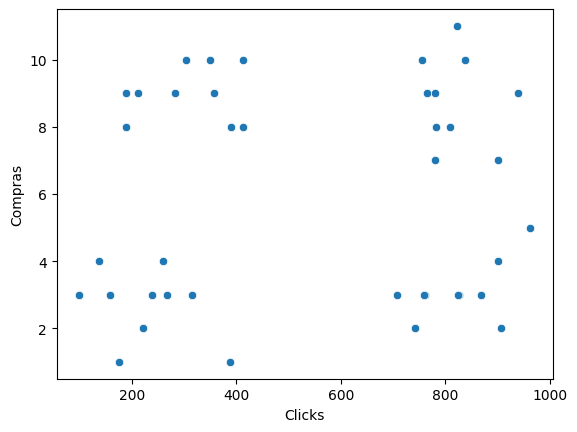

In [4]:
# Visualización con scatter plot
sns.scatterplot(data=data, x="Clicks", y="Compras")
plt.show

In [5]:
# Normalización de las variables
data_normalizada = (data - data.mean()) / (data.max() - data.min())
display(data_normalizada)

,Clicks,Compras
0,-0.322132,-0.29
1,-0.181924,-0.49
2,-0.515643,-0.29
3,-0.375435,-0.39
4,-0.447277,-0.29
5,-0.472769,-0.19
6,-0.428737,-0.49
7,-0.355736,-0.29
8,-0.331402,-0.19
9,-0.265353,-0.29


<function matplotlib.pyplot.show(close=None, block=None)>

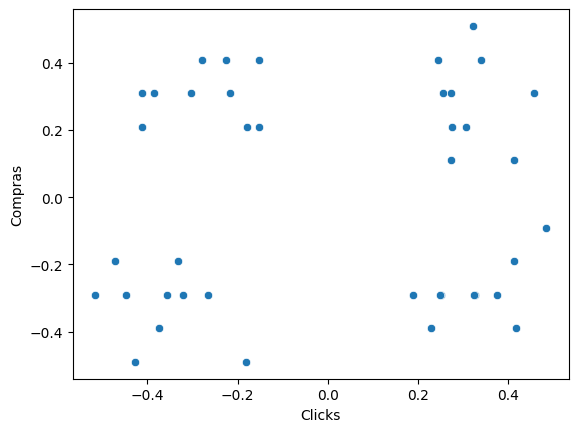

In [6]:
# Visualización con scatter plot
sns.scatterplot(data=data_normalizada, x="Clicks", y="Compras")
plt.show

In [7]:
# Dendograma

import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage

In [8]:
z = linkage(
    data_normalizada, 
    method="centroid",
    metric="euclidean")

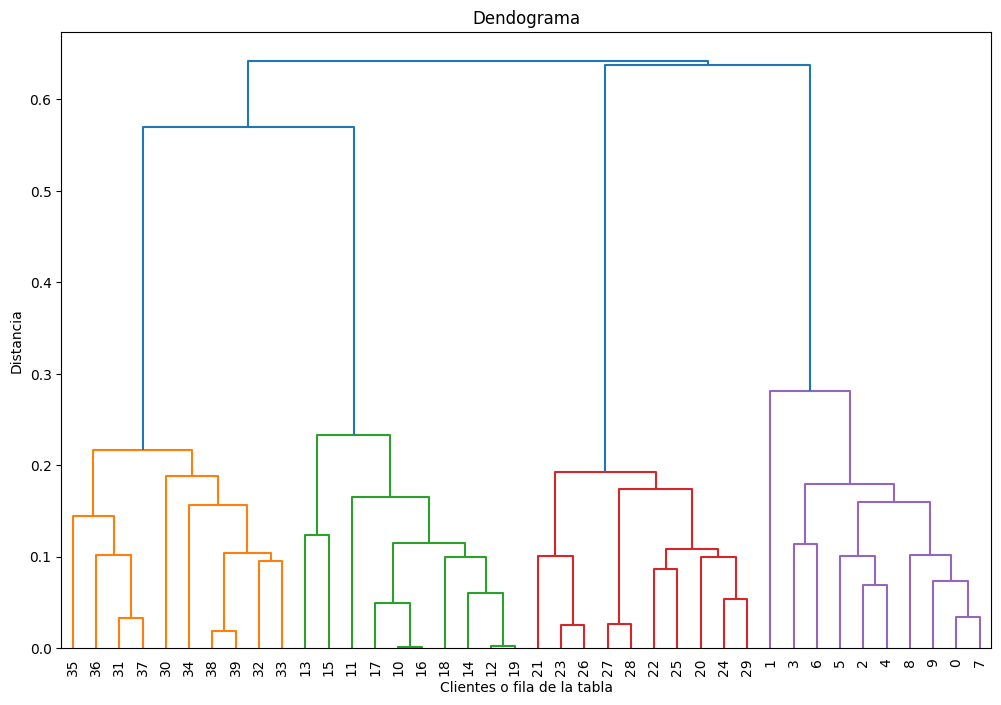

In [9]:
# Calcular la matriz de linkage si no se ha ejecutado la celda anterior
z = linkage(data_normalizada, method="centroid", metric="euclidean")

plt.figure(figsize=(12, 8))
plt.title("Dendograma")
plt.xlabel("Clientes o fila de la tabla")
plt.ylabel("Distancia")
dendrogram(z, leaf_rotation=90, leaf_font_size=10)
plt.show()

In [10]:
# Determinar el número optimo de clusters utilizando el método del codo

distancias = z[:, 2]
ultimas_distancias = distancias[:-11:-1]
ultimas_distancias

array([0.641677  , 0.63752794, 0.57007727, 0.28139374, 0.23289964,
       0.21667443, 0.19296775, 0.18860669, 0.17919183, 0.17440646])

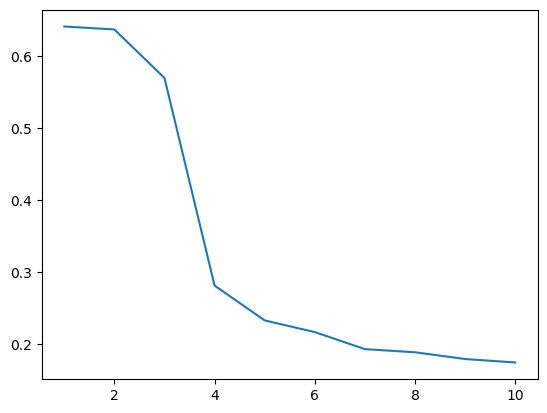

In [11]:
#Visualización del método del codo

sns.lineplot(x=range(1, len(ultimas_distancias) + 1), 
             y=ultimas_distancias
)

plt.show()